# Xarray-Spatial Dasymetric: Disaggregate, pycnophylactic interpolation, and validation

Census data comes in chunks: one population number per tract, one income figure per block group. That's useful for tables, but it hides spatial variation within each zone. Dasymetric mapping fixes this by redistributing zone totals onto a pixel grid using ancillary information like land cover or nighttime lights. xrspatial provides `disaggregate`, `pycnophylactic`, and `validate_disaggregation` for the job.

### What you'll build

1. Create synthetic census zones and a land-cover weight raster
2. Redistribute population with `disaggregate` using the binary method
3. Redistribute using the weighted (proportional) method
4. Compare binary vs. weighted side by side
5. Verify the conservation property with `validate_disaggregation`
6. Apply the limiting-variable method with density caps
7. Smooth redistribution with `pycnophylactic` interpolation (no weights needed)
8. Compare all four methods in a single view

![Dasymetric four-method comparison](images/dasymetric_comparison_preview.png)

[Synthetic data](#Synthetic-data) · [Binary method](#Binary-method) · [Weighted method](#Weighted-method) · [Comparing methods](#Comparing-methods) · [Conservation property](#Conservation-property) · [Limiting variable](#Limiting-variable-method) · [Pycnophylactic interpolation](#Pycnophylactic-interpolation) · [All four methods](#All-four-methods)

Standard imports plus the three dasymetric functions.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

from xrspatial import disaggregate
from xrspatial.dasymetric import pycnophylactic, validate_disaggregation

## Synthetic data

We need two inputs: a zone raster (which census tract each pixel belongs to) and a weight raster (ancillary information like land-cover suitability). Real workflows pull these from shapefiles and satellite imagery. Here we build them from scratch: four rectangular "census tracts" and a random weight surface with a couple of uninhabitable patches zeroed out.

In [2]:
# 20x20 zone raster with 4 "census tracts"
zones_data = np.ones((20, 20), dtype=np.float64)
zones_data[:10, :10] = 1
zones_data[:10, 10:] = 2
zones_data[10:, :10] = 3
zones_data[10:, 10:] = 4

zones = xr.DataArray(zones_data, dims=['y', 'x'])

# Population per tract
population = {1: 1000.0, 2: 500.0, 3: 2000.0, 4: 300.0}

# Ancillary weight raster: simulates land-cover suitability
np.random.seed(42)
weight_data = np.random.rand(20, 20).astype(np.float64)
weight_data[0:3, 0:3] = 0.0   # water body in tract 1
weight_data[14:18, 14:18] = 0.0  # park in tract 4

weight = xr.DataArray(weight_data, dims=['y', 'x'])

Four zones with different population totals (1000, 500, 2000, 300). The weight surface has two dead patches: a "water body" in the top-left corner of tract 1 and a "park" in tract 4. Pixels in those patches get zero weight, so no population should land there.

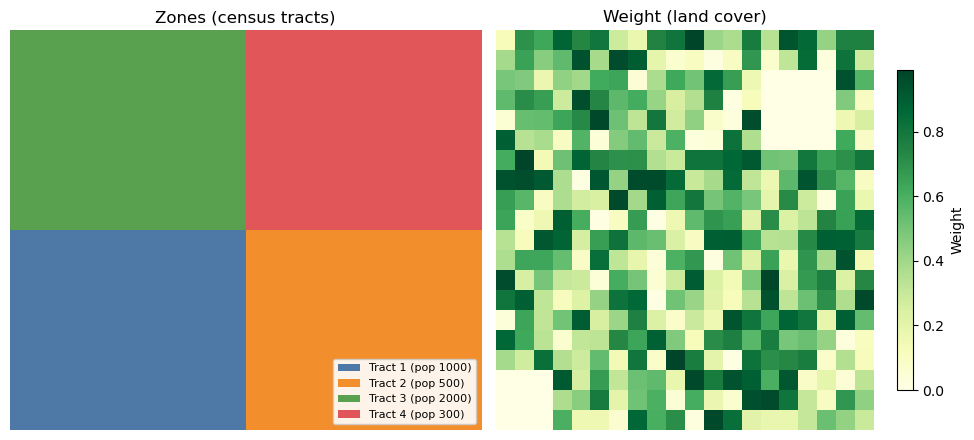

In [3]:
zone_cmap = ListedColormap(['#4e79a7', '#f28e2b', '#59a14f', '#e15759'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

zones.plot.imshow(ax=axes[0], cmap=zone_cmap, add_colorbar=False)
axes[0].set_title('Zones (census tracts)', fontsize=12)
axes[0].legend(handles=[
    Patch(facecolor='#4e79a7', label='Tract 1 (pop 1000)'),
    Patch(facecolor='#f28e2b', label='Tract 2 (pop 500)'),
    Patch(facecolor='#59a14f', label='Tract 3 (pop 2000)'),
    Patch(facecolor='#e15759', label='Tract 4 (pop 300)'),
], loc='lower right', fontsize=8, framealpha=0.9)
axes[0].set_axis_off()

weight.plot.imshow(ax=axes[1], cmap='YlGn', add_colorbar=True,
                   cbar_kwargs={'label': 'Weight', 'shrink': 0.8})
axes[1].set_title('Weight (land cover)', fontsize=12)
axes[1].set_axis_off()

plt.tight_layout()

## Binary method

The simplest approach. `disaggregate` with `method='binary'` ignores the actual weight values and just checks whether each pixel is habitable (nonzero weight) or not. Every habitable pixel in a zone gets an equal share of the zone's total. The result is a flat density surface within each zone, with gaps where weight is zero.

The plot below shows per-pixel population after binary redistribution.

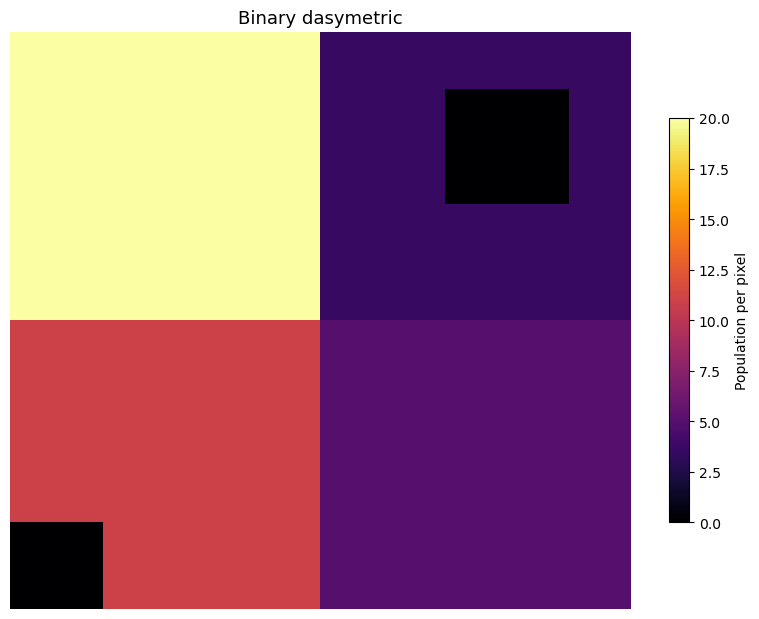

In [4]:
result_binary = disaggregate(zones, population, weight, method='binary')

fig, ax = plt.subplots(figsize=(10, 7.5))
result_binary.plot.imshow(ax=ax, cmap='inferno', add_colorbar=True,
                          cbar_kwargs={'label': 'Population per pixel', 'shrink': 0.7})
ax.set_title('Binary dasymetric', fontsize=13)
ax.set_axis_off()

## Weighted method

The default. Instead of treating all habitable pixels the same, `method='weighted'` distributes each zone's total in proportion to weight values:

pixel = zone_value * pixel_weight / sum(weights in zone)

Higher-weight pixels get more population. This is the standard [dasymetric mapping](https://en.wikipedia.org/wiki/Dasymetric_map) approach and the one you'd normally reach for when you have continuous ancillary data.

The plot shows per-pixel population after weighted redistribution. Compare the variation within each zone to the flat result from binary above.

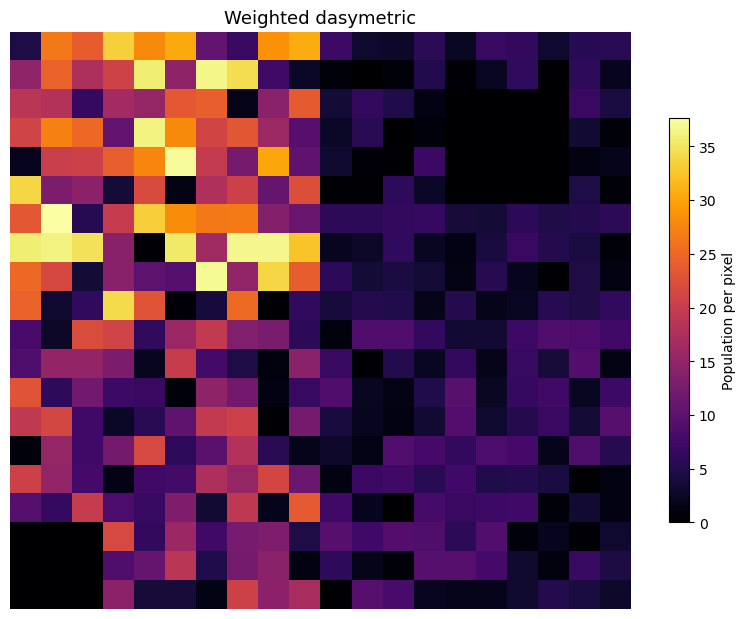

In [5]:
result_weighted = disaggregate(zones, population, weight, method='weighted')

fig, ax = plt.subplots(figsize=(10, 7.5))
result_weighted.plot.imshow(ax=ax, cmap='inferno', add_colorbar=True,
                            cbar_kwargs={'label': 'Population per pixel', 'shrink': 0.7})
ax.set_title('Weighted dasymetric', fontsize=13)
ax.set_axis_off()

## Comparing methods

Side by side, binary produces uniform blocks (same value for every habitable pixel in a zone) while weighted produces spatial variation that follows the weight surface. Both respect the same zero-weight gaps.

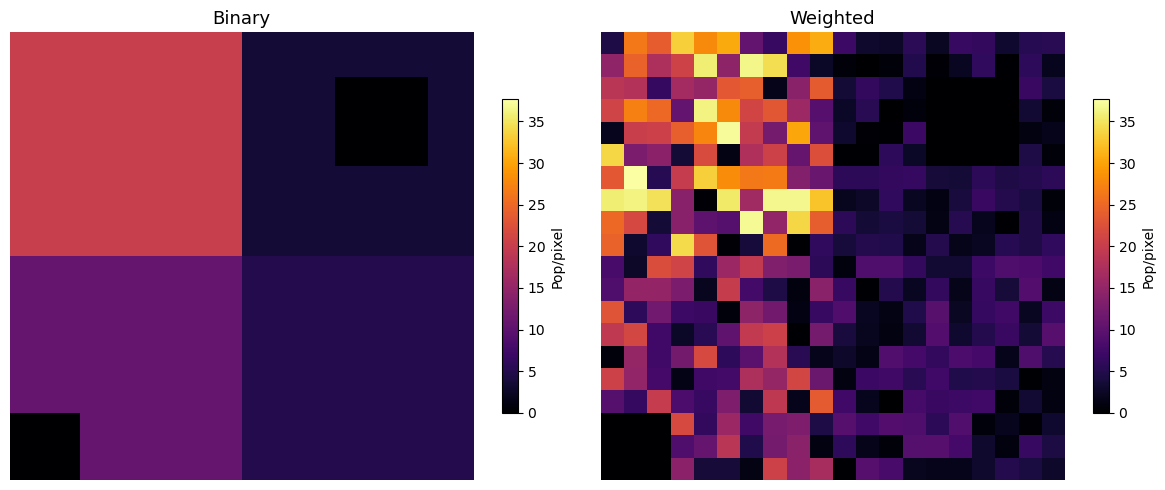

In [6]:
vmax = float(np.nanmax([np.nanmax(result_binary.values),
                        np.nanmax(result_weighted.values)]))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

result_binary.plot.imshow(ax=axes[0], cmap='inferno', vmin=0, vmax=vmax,
                          add_colorbar=True,
                          cbar_kwargs={'label': 'Pop/pixel', 'shrink': 0.7})
axes[0].set_title('Binary', fontsize=13)
axes[0].set_axis_off()

result_weighted.plot.imshow(ax=axes[1], cmap='inferno', vmin=0, vmax=vmax,
                            add_colorbar=True,
                            cbar_kwargs={'label': 'Pop/pixel', 'shrink': 0.7})
axes[1].set_title('Weighted', fontsize=13)
axes[1].set_axis_off()

plt.tight_layout()

<div class="alert alert-block alert-warning">
<b>Weight quality matters.</b> The weighted method is only as good as the ancillary data driving it. If the weight raster doesn't correlate with the variable you're redistributing (e.g., using vegetation index to redistribute industrial employment), the output will look smooth but be misleading. Always check that the weight proxy makes physical sense for your target variable.
</div>

## Conservation property

A defining feature of dasymetric mapping: the sum of output pixel values within each zone must equal the original zone total. If you redistribute 1000 people across tract 1, the pixel values in tract 1 should add up to exactly 1000.

`validate_disaggregation` checks this automatically. It compares per-zone sums against the input values and raises an error if any zone exceeds the tolerance. Below we run it on the weighted result and also print the numbers manually.

In [7]:
# Automated check: raises ValueError if any zone total is off
is_valid = validate_disaggregation(result_weighted, zones, population)
print(f'validate_disaggregation passed: {is_valid}\n')

# Manual check: print per-zone totals
for zid, expected in population.items():
    actual = float(np.nansum(result_weighted.values[zones_data == zid]))
    print(f'Zone {zid}: expected={expected:.1f}, actual={actual:.1f}, '
          f'diff={abs(expected - actual):.2e}')

validate_disaggregation passed: True

Zone 1: expected=1000.0, actual=1000.0, diff=0.00e+00
Zone 2: expected=500.0, actual=500.0, diff=5.68e-14
Zone 3: expected=2000.0, actual=2000.0, diff=4.55e-13
Zone 4: expected=300.0, actual=300.0, diff=1.14e-13


## Limiting-variable method

The [three-class dasymetric method](https://doi.org/10.1559/152304003100011081) adds density caps per land-cover class. The idea: you know that residential areas can hold at most N people per pixel, commercial areas at most M, and water holds zero. The algorithm fills each class up to its cap, then redistributes any leftover to other classes.

`method='limiting_variable'` applies this logic. It classifies pixels by their weight value (using `class_breaks`) and applies `density_caps` per class. Currently numpy-only.

The plot shows the result with a two-class split (zero-weight vs. nonzero-weight) and default caps.

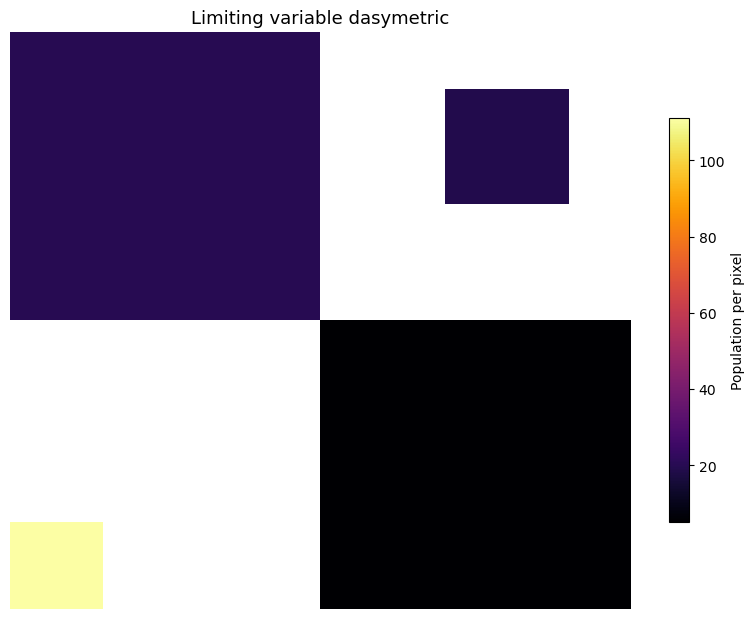

In [8]:
result_lv = disaggregate(zones, population, weight, method='limiting_variable')

fig, ax = plt.subplots(figsize=(10, 7.5))
result_lv.plot.imshow(ax=ax, cmap='inferno', add_colorbar=True,
                      cbar_kwargs={'label': 'Population per pixel', 'shrink': 0.7})
ax.set_title('Limiting variable dasymetric', fontsize=13)
ax.set_axis_off()

<div class="alert alert-block alert-info">
<b>Backend support.</b> The binary and weighted methods run on all four backends (numpy, cupy, dask+numpy, dask+cupy). The limiting-variable method is numpy-only because its iterative redistribution loop doesn't parallelize cleanly. If you need dask support for large rasters, use the weighted method instead.
</div>

## Pycnophylactic interpolation

[Tobler's pycnophylactic interpolation](https://doi.org/10.1080/01621459.1979.10481647) takes a different approach. It doesn't need an ancillary weight raster at all. Instead, it starts by assigning each pixel a uniform share of its zone total, then iteratively smooths the surface with a Laplacian filter while rescaling each zone to preserve its original sum. The result is a smooth surface that respects zone boundaries and conserves totals.

This works well when you don't have ancillary data or when you want a smooth baseline to compare against weight-based methods.

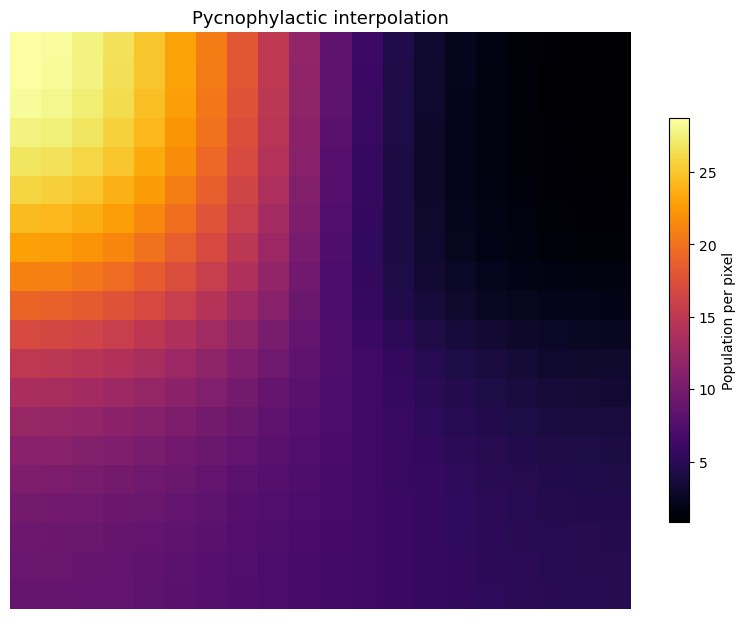

In [9]:
result_pycno = pycnophylactic(zones, population, max_iterations=200)

fig, ax = plt.subplots(figsize=(10, 7.5))
result_pycno.plot.imshow(ax=ax, cmap='inferno', add_colorbar=True,
                         cbar_kwargs={'label': 'Population per pixel', 'shrink': 0.7})
ax.set_title('Pycnophylactic interpolation', fontsize=13)
ax.set_axis_off()

The smooth gradients within each zone come from the Laplacian averaging. Population concentrates toward zone centers and tapers off at edges. No ancillary data was involved, just the geometry of the zones.

## All four methods

For fun, here are all four redistribution approaches on a shared color scale. Binary is flat within each zone. Weighted follows the weight surface. Limiting variable looks similar to weighted here (the default density caps are infinite, so it falls back to equal distribution). Pycnophylactic is smooth and symmetric, driven purely by zone geometry.

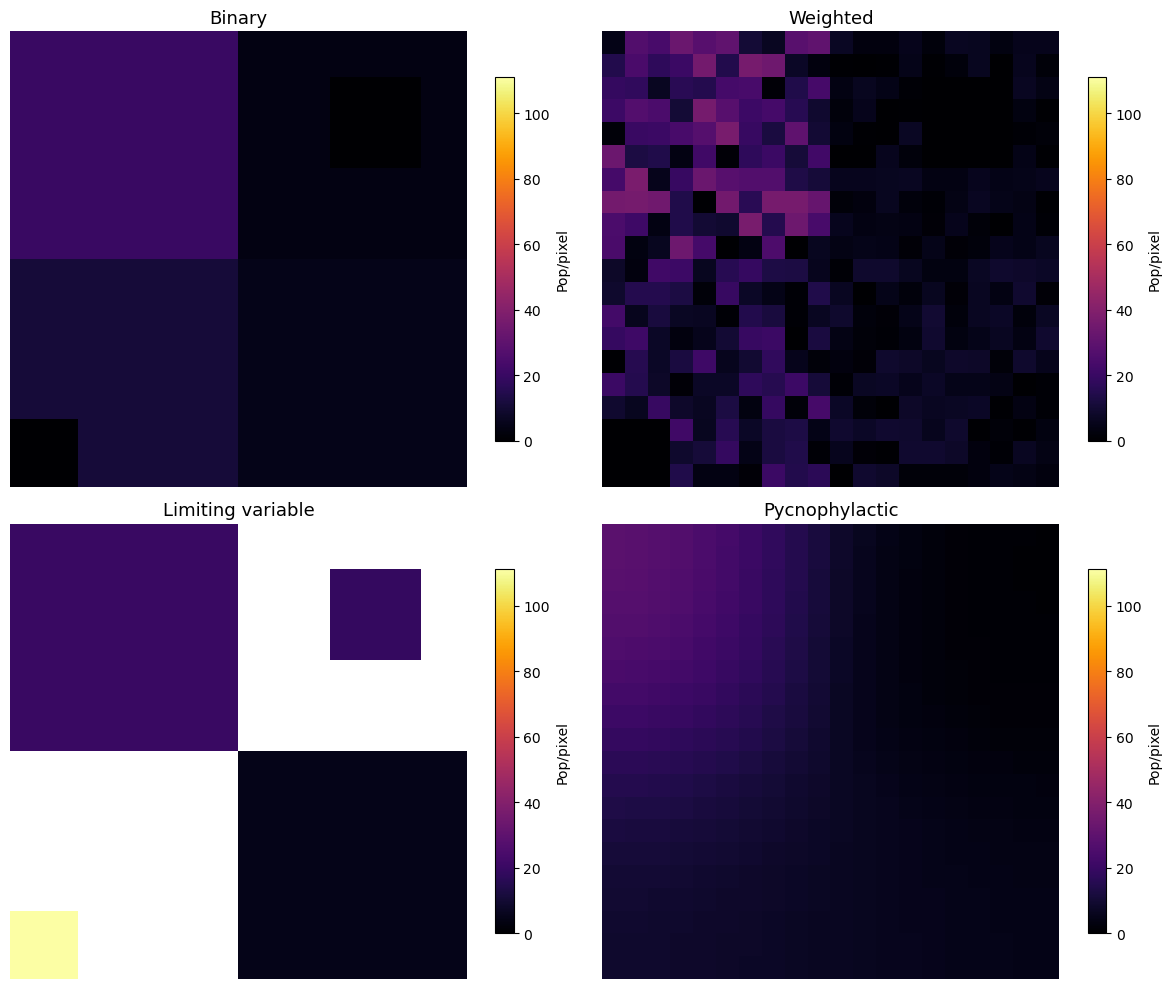

In [10]:
all_vals = np.concatenate([
    result_binary.values.ravel(),
    result_weighted.values.ravel(),
    result_lv.values.ravel(),
    result_pycno.values.ravel(),
])
vmin_all = 0
vmax_all = float(np.nanmax(all_vals))

results = [result_binary, result_weighted, result_lv, result_pycno]
titles = ['Binary', 'Weighted', 'Limiting variable', 'Pycnophylactic']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, data, title in zip(axes.ravel(), results, titles):
    data.plot.imshow(ax=ax, cmap='inferno', vmin=vmin_all, vmax=vmax_all,
                     add_colorbar=True,
                     cbar_kwargs={'label': 'Pop/pixel', 'shrink': 0.8})
    ax.set_title(title, fontsize=13)
    ax.set_axis_off()
plt.tight_layout()

# Save preview image
import pathlib
pathlib.Path('images').mkdir(exist_ok=True)
fig.savefig('images/dasymetric_comparison_preview.png',
            bbox_inches='tight', dpi=120)

### References

- [Dasymetric map](https://en.wikipedia.org/wiki/Dasymetric_map), Wikipedia
- Mennis, J. (2003). "Generating Surface Models of Population Using Dasymetric Mapping." *The Professional Geographer*, 55(1), 31-42. [doi:10.1559/152304003100011081](https://doi.org/10.1559/152304003100011081)
- Tobler, W. R. (1979). "Smooth Pycnophylactic Interpolation for Geographical Regions." *Journal of the American Statistical Association*, 74(367), 519-530. [doi:10.1080/01621459.1979.10481647](https://doi.org/10.1080/01621459.1979.10481647)
- [xrspatial dasymetric API docs](https://makepath.github.io/xarray-spatial/reference/_autosummary/xrspatial.dasymetric.html)